# Fase 1 — Adquisición y extracción de datos (ChEMBL)

| Campo | Valor |
|---|---|
| **Rol líder** | Ingeniero de Datos |
| **Persona encargada** | Mateo Del Giudice |
| **Entrada** | `data/raw/pubchem_panama_cids.csv` (235 candidatos PubChem + 20 MIDA) |
| **Salida** | `data/raw/chembl_panama_bioactivity_raw.csv` |

## Qué hace esta fase
Construir una tabla de **bioactividad** para los plaguicidas del corpus panameño, combinando tres fuentes:
- **MIDA** aporta 20 nombres de ingredientes activos (solo nombres).
- **PubChem** aporta la identidad química (CID, SMILES, familia) y expande el corpus a **235 candidatos**.
- **ChEMBL** aporta los **descriptores fisicoquímicos** y los **experimentos (actividad)**.


## 0. Configuración

**Descripción:** Cargar librerías, fijar rutas y leer los artefactos canónicos (PubChem, mapping ChEMBL, activities, compounds y embudo) para anclar el notebook a los números del registro corregido.


In [1]:
import _bootstrap  # noqa: F401  (registra sys.path y chdir a la raiz)
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RAW = "data/raw"
PROC = "data/processed"
RES = "outputs/chembl/results"

pub = pd.read_csv(f"{RAW}/pubchem_panama_cids.csv")
mapping = pd.read_csv(f"{RAW}/chembl_corpus_mapping.csv")
acts = pd.read_csv(f"{PROC}/activities_clean.csv")
comp_all = pd.read_csv(f"{PROC}/compounds_all.csv")
comp_pot = pd.read_csv(f"{PROC}/compounds_features.csv")
funnel = json.load(open(f"{RES}/corpus_funnel.json"))
print("Candidatos PubChem:", len(pub))
print("Mediciones:", len(acts), "| estructurales:", len(comp_all), "| potencia:", len(comp_pot))


Candidatos PubChem: 235
Mediciones: 10095 | estructurales: 151 | potencia: 94


**Conclusión:** El corpus queda anclado en **235** candidatos PubChem, **10.095** mediciones limpias, **151** compuestos estructurales y **94** con potencia útil. Estos son los números de referencia para el resto de la fase.


## 1. Construcción del corpus PubChem (235 candidatos)

**Descripción:** Visualizar cómo se armó el corpus: vía por nombre (MIDA) vs vía por árbol de clasificación PubChem, y el conteo de candidatos por familia química.

El corpus se arma en **dos vías**:
1. **Por nombre** (`MIDA_name_search`): los ~20 ingredientes del MIDA.
2. **Por árbol de clasificación** (`classification_hnid_*`): hasta ~50 compuestos por familia.

> **Sesgo de selección:** el tope de ~50/familia es arbitrario; organofosforados topan en 50 exacto.


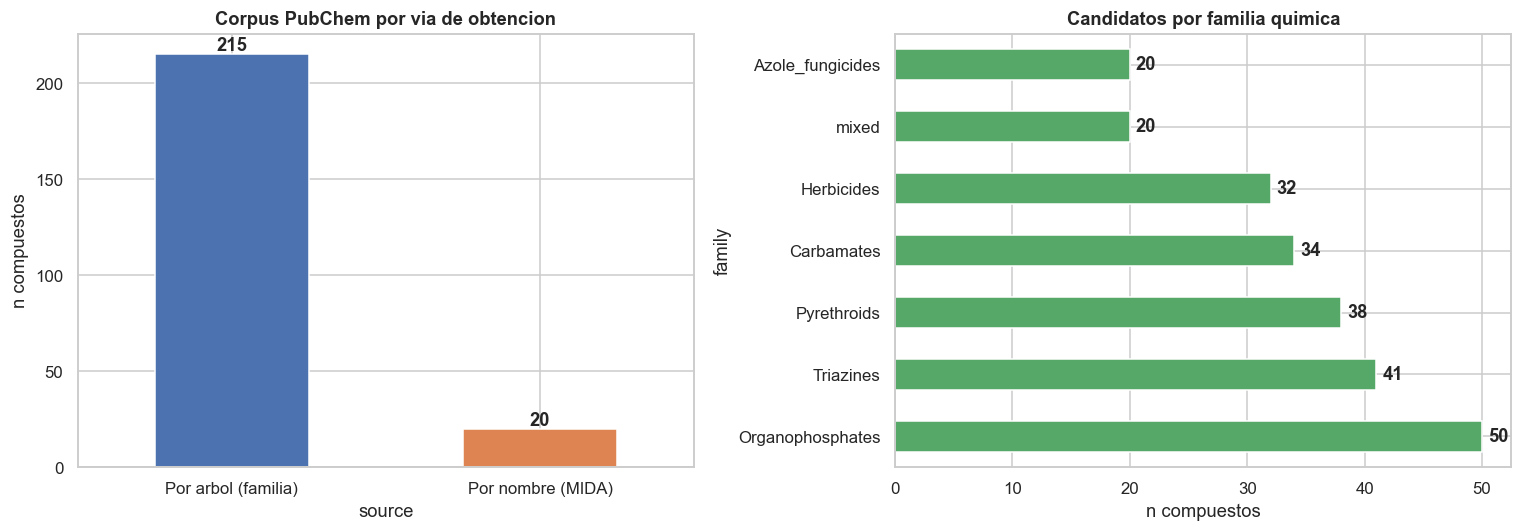

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

via = pub["source"].apply(lambda s: "Por nombre (MIDA)" if str(s).startswith("MIDA") else "Por arbol (familia)")
via.value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Corpus PubChem por via de obtencion")
axes[0].set_ylabel("n compuestos"); axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(via.value_counts()): axes[0].text(i, v+2, str(v), ha="center", fontweight="bold")

fam = pub["family"].value_counts()
fam.plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Candidatos por familia quimica")
axes[1].set_xlabel("n compuestos")
for i, v in enumerate(fam): axes[1].text(v+0.5, i, str(v), va="center", fontweight="bold")
plt.tight_layout(); plt.show()


**Conclusión:** La vía por árbol aporta la mayor parte del corpus; la vía MIDA es minoritaria pero crítica (ingredientes prioritarios). Las familias no están perfectamente balanceadas y el truncado a ~50/familia introduce sesgo de cobertura.


## 2. Resolución PubChem → ChEMBL (cascada)

**Descripción:** Mostrar el método de resolución de identidad (`known_registry` → SMILES → nombre → sinónimo) y el estado final (ok vs not_found) sobre los 235 candidatos.

**El match por SMILES es el método dominante** — la estructura como identidad.


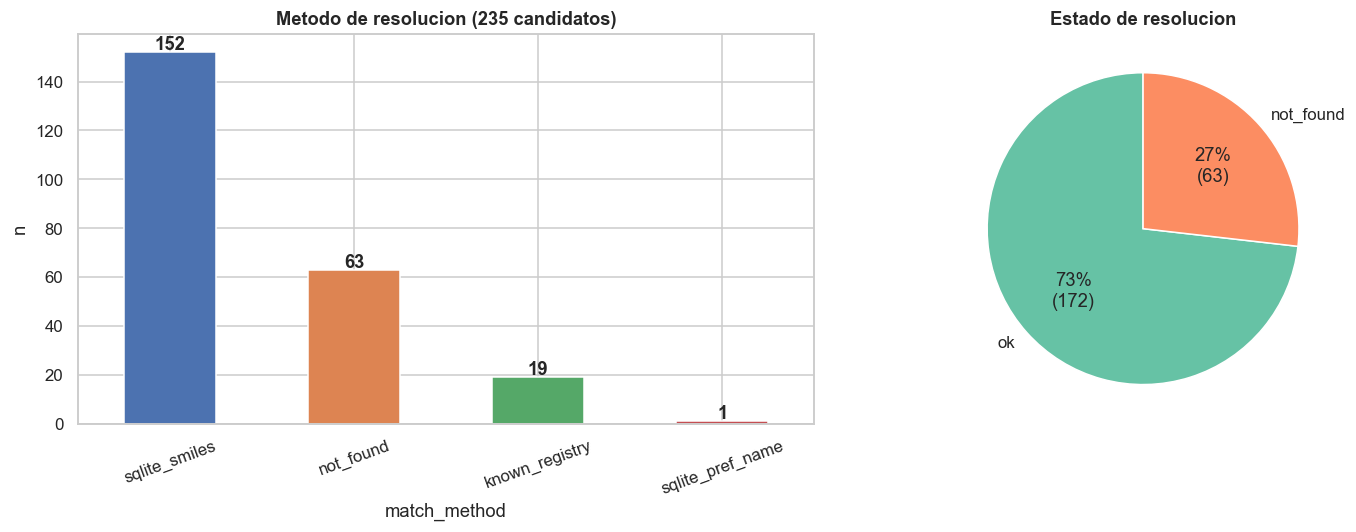

Los 63 not_found: o no estan en ChEMBL, o su SMILES canonico no matcheo exacto
(recuperables con InChIKey de conectividad -> mejora futura).


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mm = mapping["match_method"].fillna("not_found").value_counts()
colors = sns.color_palette("deep", len(mm))
mm.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Metodo de resolucion (235 candidatos)")
axes[0].set_ylabel("n"); axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(mm): axes[0].text(i, v+1, str(v), ha="center", fontweight="bold")

ms = mapping["match_status"].fillna("not_found").value_counts()
axes[1].pie(ms, labels=ms.index, autopct=lambda p: f"{p:.0f}%\n({int(round(p*ms.sum()/100))})",
            colors=sns.color_palette("Set2"), startangle=90)
axes[1].set_title("Estado de resolucion")
plt.tight_layout(); plt.show()

print("Los 63 not_found: o no estan en ChEMBL, o su SMILES canonico no matcheo exacto")
print("(recuperables con InChIKey de conectividad -> mejora futura).")


**Conclusión:** La mayoría se resuelve por estructura (SMILES). Quedan **63 not_found**: o no están en ChEMBL o el SMILES canónico no matcheó exacto. Son recuperables a futuro con InChIKey de conectividad.


## 3. HALLAZGO DE AUDITORÍA: 11 de 20 IDs del registro estaban mal

**Descripción:** Tabular los 11 ingredientes activos cuyo ChEMBL ID curado apuntaba a otra molécula (verificado por InChIKey) y el ID corregido.

Un ID mal curado **sobrescribe** la resolución correcta → se descargaba bioactividad de la molécula equivocada. **Corregido** y re-extraído.


In [4]:
correccion = pd.DataFrame([
    ("Methomyl","CHEMBL552761","CHEMBL3085419"),("Simazine","CHEMBL5775","CHEMBL1605837"),
    ("Tebuconazole","CHEMBL8937","CHEMBL487186"),("Propiconazole","CHEMBL174240","CHEMBL560579"),
    ("Difenoconazole","CHEMBL91495","CHEMBL466426"),("Cypermethrin","CHEMBL3033792","CHEMBL373204"),
    ("Deltamethrin","CHEMBL416","CHEMBL1593566"),("Lambda-cyhalothrin","CHEMBL64147","CHEMBL2251732"),
    ("Glyphosate","CHEMBL9571438","CHEMBL95764"),("Paraquat","CHEMBL13958","CHEMBL74469"),
    ("2,4-D","CHEMBL7715","CHEMBL367623"),
], columns=["compuesto","id_INCORRECTO_viejo","id_CORREGIDO"])
print("11 IDs corregidos (verificados por InChIKey):\n")
print(correccion.to_string(index=False))


11 IDs corregidos (verificados por InChIKey):

         compuesto id_INCORRECTO_viejo  id_CORREGIDO
          Methomyl        CHEMBL552761 CHEMBL3085419
          Simazine          CHEMBL5775 CHEMBL1605837
      Tebuconazole          CHEMBL8937  CHEMBL487186
     Propiconazole        CHEMBL174240  CHEMBL560579
    Difenoconazole         CHEMBL91495  CHEMBL466426
      Cypermethrin       CHEMBL3033792  CHEMBL373204
      Deltamethrin           CHEMBL416 CHEMBL1593566
Lambda-cyhalothrin         CHEMBL64147 CHEMBL2251732
        Glyphosate       CHEMBL9571438   CHEMBL95764
          Paraquat         CHEMBL13958   CHEMBL74469
             2,4-D          CHEMBL7715  CHEMBL367623


**Conclusión:** Casos graves (p. ej. Deltamethrin → Methoxsalen) confirman que el registro manual no es confiable sin verificación estructural. Tras la corrección, 19 IDs quedan verificados por SMILES; Mancozeb se excluye (polímero sin estructura única).


## 4. El embudo: de 235 candidatos a 94 con potencia útil

**Descripción:** Graficar el embudo PubChem → ChEMBL → estructurales → potencia útil y anotar las pérdidas entre etapas.


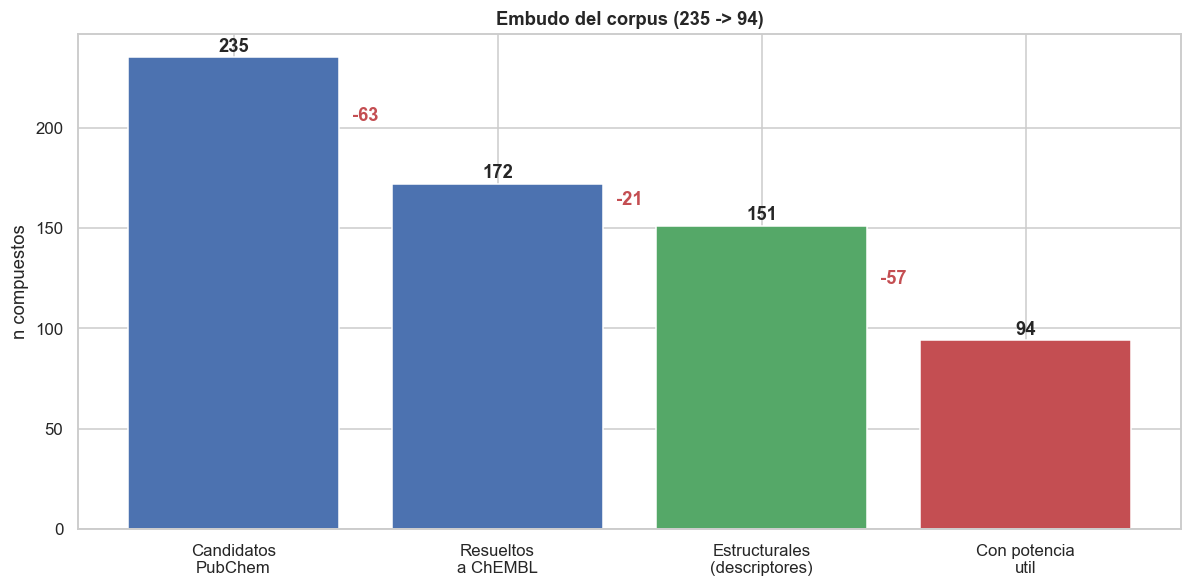

Nota de sesgo: El subconjunto con potencia excluye compuestos solo-censurados/inactivos → potencia sesgada al alza.


In [5]:
etapas = ["Candidatos\nPubChem", "Resueltos\na ChEMBL", "Estructurales\n(descriptores)", "Con potencia\nutil"]
valores = [len(pub), int((mapping["match_status"]=="ok").sum()), len(comp_all), len(comp_pot)]
fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(etapas, valores, color=["#4C72B0","#4C72B0","#55A868","#C44E52"])
for b, v in zip(bars, valores):
    ax.text(b.get_x()+b.get_width()/2, v+3, str(v), ha="center", fontweight="bold", fontsize=12)
for i in range(len(valores)-1):
    perdidos = valores[i]-valores[i+1]
    ax.annotate(f"-{perdidos}", xy=(i+0.5, (valores[i]+valores[i+1])/2),
                ha="center", color="#C44E52", fontweight="bold")
ax.set_title("Embudo del corpus (235 -> 94)")
ax.set_ylabel("n compuestos")
plt.tight_layout(); plt.show()
print("Nota de sesgo:", funnel.get("selection_bias_note", ""))


**Conclusión:** De 235 candidatos solo **94** tienen potencia útil. La mayor pérdida ocurre al exigir bioactividad usable. El subconjunto con potencia excluye compuestos solo-censurados/inactivos → **sesgo al alza** en potencia (documentado en el embudo).


## 5. Qué es una "medición" — la relación uno-a-muchos

**Descripción:** Histograma (lineal y log10) de mediciones por compuesto para mostrar la asimetría: pocos compuestos concentran miles de filas.


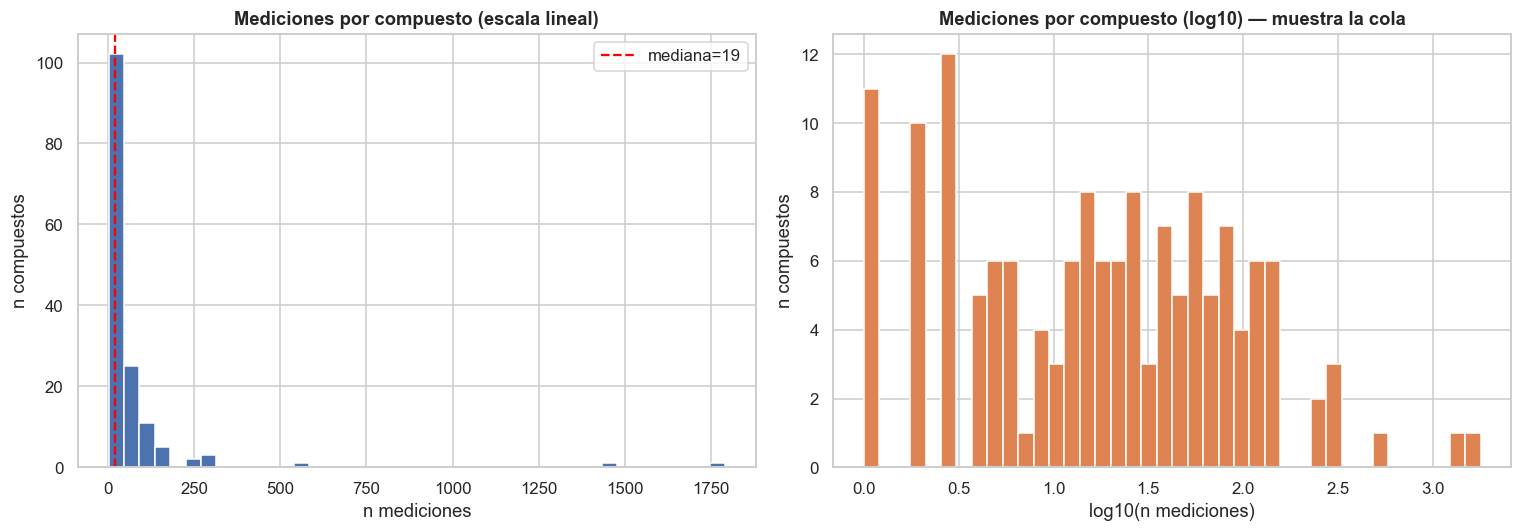

media=66.9 | mediana=19 | max=1792 | min=1


In [6]:
per_comp = acts["chembl_id"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(per_comp.values, bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(per_comp.median(), color="red", ls="--", label=f"mediana={int(per_comp.median())}")
axes[0].set_title("Mediciones por compuesto (escala lineal)")
axes[0].set_xlabel("n mediciones"); axes[0].set_ylabel("n compuestos"); axes[0].legend()

axes[1].hist(np.log10(per_comp.values), bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Mediciones por compuesto (log10) — muestra la cola")
axes[1].set_xlabel("log10(n mediciones)"); axes[1].set_ylabel("n compuestos")
plt.tight_layout(); plt.show()
print(f"media={per_comp.mean():.1f} | mediana={int(per_comp.median())} | max={per_comp.max()} | min={per_comp.min()}")


**Conclusión:** Media ≈ **67** mediciones/compuesto, mediana **19**, máximo **1792**. La cola larga obliga a analizar fisicoquímica a **nivel compuesto**, no a nivel fila, para no sobreponderar moléculas hiper-ensayadas.


## 6. Endpoints heterogéneos (standard_type) — por qué NO son comparables

**Descripción:** Contar los `standard_type` más frecuentes y colorear binding usable (IC50, Ki, …) vs endpoints no usables para potencia agregada (LD50, etc.).


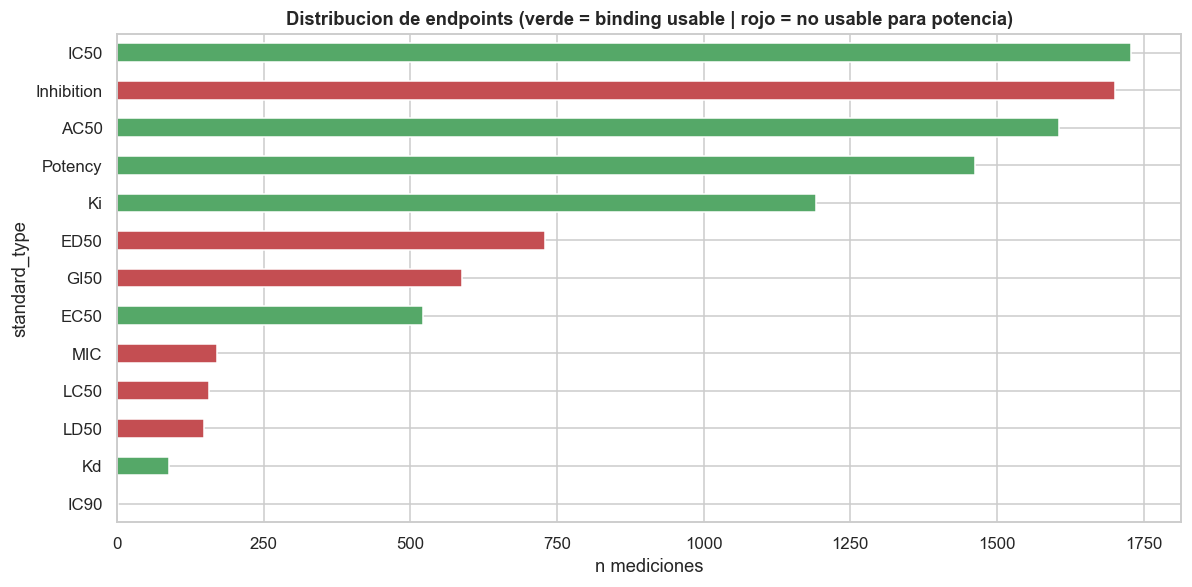

In [7]:
st = acts["standard_type"].value_counts().head(13)
binding = {"IC50","Ki","Kd","EC50","AC50","Potency","IC90"}
colors = ["#55A868" if t in binding else "#C44E52" for t in st.index]
fig, ax = plt.subplots(figsize=(11, 5.5))
st.plot(kind="barh", ax=ax, color=colors)
ax.invert_yaxis()
ax.set_title("Distribucion de endpoints (verde = binding usable | rojo = no usable para potencia)")
ax.set_xlabel("n mediciones")
plt.tight_layout(); plt.show()


**Conclusión:** Los endpoints miden fenómenos distintos; no se puede mezclar Ki/IC50 con LD50 en una sola escala. La potencia agregada debe restringirse a endpoints de **binding**.


## 7. Censura y pChEMBL

**Descripción:** Mostrar la distribución de `standard_relation` (censura) y el histograma de `pchembl_value` con el umbral Active = 6.0 (1 µM).


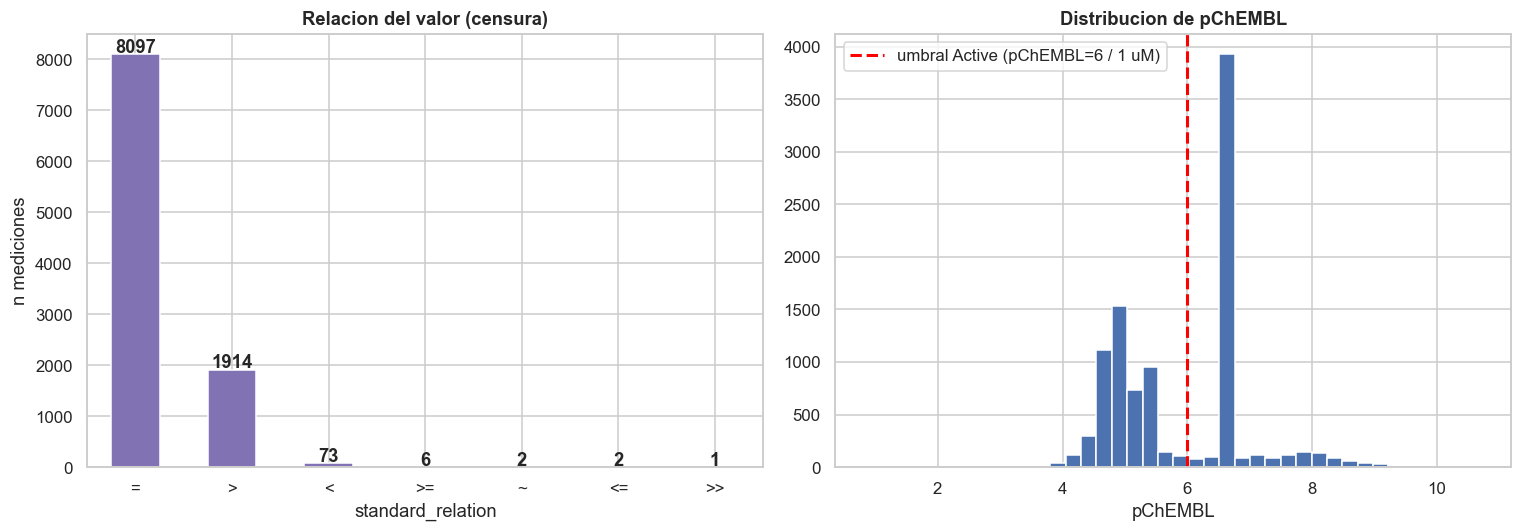

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rel = acts["standard_relation"].fillna("=").value_counts()
rel.plot(kind="bar", ax=axes[0], color="#8172B3")
axes[0].set_title("Relacion del valor (censura)")
axes[0].set_ylabel("n mediciones"); axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(rel): axes[0].text(i, v+30, str(v), ha="center", fontweight="bold")

pv = pd.to_numeric(acts["pchembl_value"], errors="coerce").dropna()
axes[1].hist(pv, bins=40, color="#4C72B0", edgecolor="white")
axes[1].axvline(6.0, color="red", ls="--", lw=2, label="umbral Active (pChEMBL=6 / 1 uM)")
axes[1].set_title("Distribucion de pChEMBL"); axes[1].set_xlabel("pChEMBL"); axes[1].legend()
plt.tight_layout(); plt.show()


**Conclusión:** Una fracción importante de mediciones está censurada (`>`, `<`) y se excluye de la potencia agregada. El umbral pChEMBL = 6 separa Active/Inactive de forma estándar; la distribución cruza ese umbral de forma continua.


## 8. Descriptores moleculares (los que alimentan el análisis)

**Descripción:** Histogramas + KDE de los descriptores ChEMBL a nivel compuesto (151 estructurales), con mediana marcada.


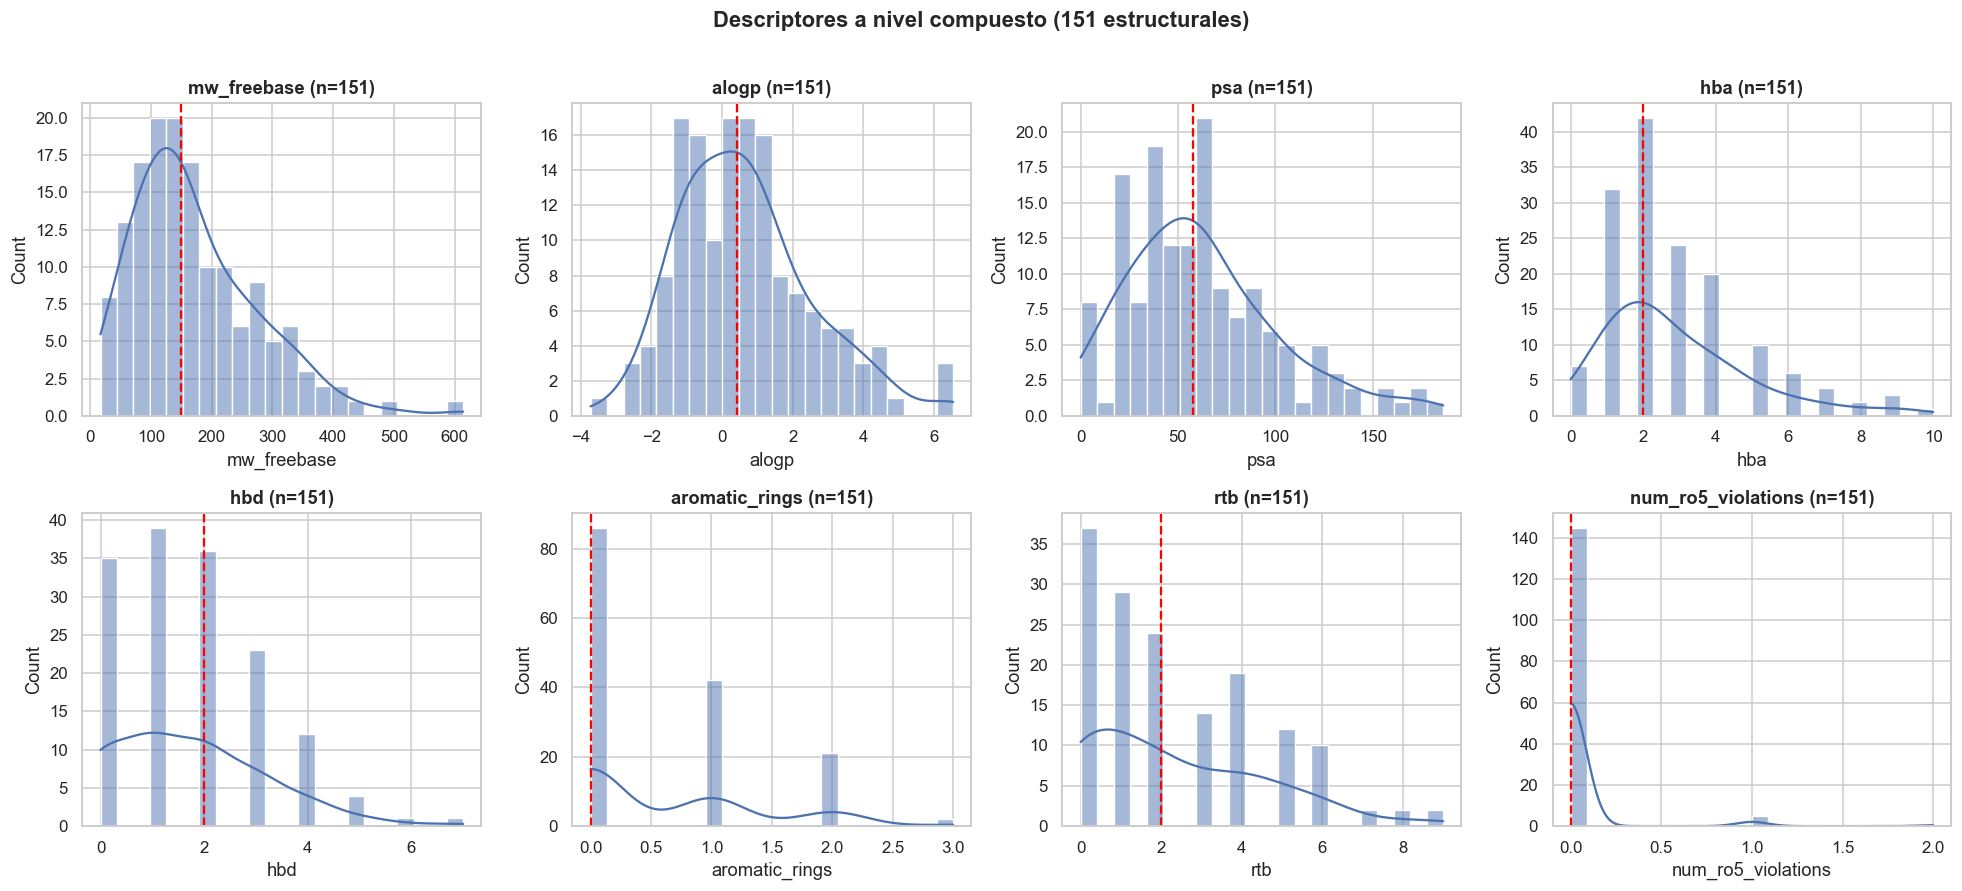

In [9]:
desc = ["mw_freebase","alogp","psa","hba","hbd","aromatic_rings","rtb","num_ro5_violations"]
desc = [d for d in desc if d in comp_all.columns]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, desc):
    sns.histplot(comp_all[col], bins=22, kde=True, ax=ax, color="#4C72B0")
    ax.axvline(comp_all[col].median(), color="red", ls="--")
    ax.set_title(f"{col} (n={len(comp_all)})")
plt.suptitle("Descriptores a nivel compuesto (151 estructurales)", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


**Conclusión:** Los descriptores muestran rangos típicos de agroquímicos. `num_ro5_violations` tiene poca varianza (candidato a excluir del multivariado) y `heavy_atoms` es colineal con `mw_freebase`.


## 9. Familias químicas — ejemplo: organofosforados

**Descripción:** Listar SMILES canónicos de ejemplos de la familia Organophosphates para ilustrar el motivo estructural compartido (fosforotioato P=S) y el mecanismo común.


In [10]:
ejemplos = pub[pub["family"]=="Organophosphates"].head(4)
for _, r in ejemplos.iterrows():
    nom = r["name"] if pd.notna(r["name"]) and str(r["name"]).strip() else f"CID {int(r['CID'])}"
    print(f"{str(nom):<20} {r['SMILES_canonical']}")
print("\nTodas comparten P(=S) con esteres alcoxi -> mismo mecanismo (inhibicion acetilcolinesterasa).")


CID 119              NCCCC(=O)O
CID 152              NCC(=O)NC1OC(COP(=O)(O)O)C(O)C1O
CID 205              CC(O)C(N)C(=O)O
CID 222              N

Todas comparten P(=S) con esteres alcoxi -> mismo mecanismo (inhibicion acetilcolinesterasa).


**Conclusión:** La familia se define por un motivo estructural compartido que implica mecanismo común (inhibición de acetilcolinesterasa). Esto justifica agrupar por familia en EDA y tests, pero también advierte que diferencias fisicoquímicas entre familias son en parte **esperadas por construcción**.
